# Task 2 - Image generation using pretrained model
using stable diffusion to generate images from text, model is already trained so just using it directly

In [4]:
!pip install keras-cv tensorflow -q

In [5]:
import keras_cv
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


loading the model, this takes a min or two first time since it downloads weights

In [6]:
import keras
keras.mixed_precision.set_global_policy("mixed_float16") # makes it faster on gpu

model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


## giving it a prompt
just testing with something random first

In [7]:
prompt = "a futuristic city skyline at sunset, digital art"

imgs = model.text_to_image(prompt, batch_size=3)

1356917/1356917 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
492466864/492466864 ━━━━━━━━━━━━━━━━━━━━ 300s 1us/step
3439090152/3439090152 ━━━━━━━━━━━━━━━━━━━━ 384s 0us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 494s 575ms/step
198180272/198180272 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


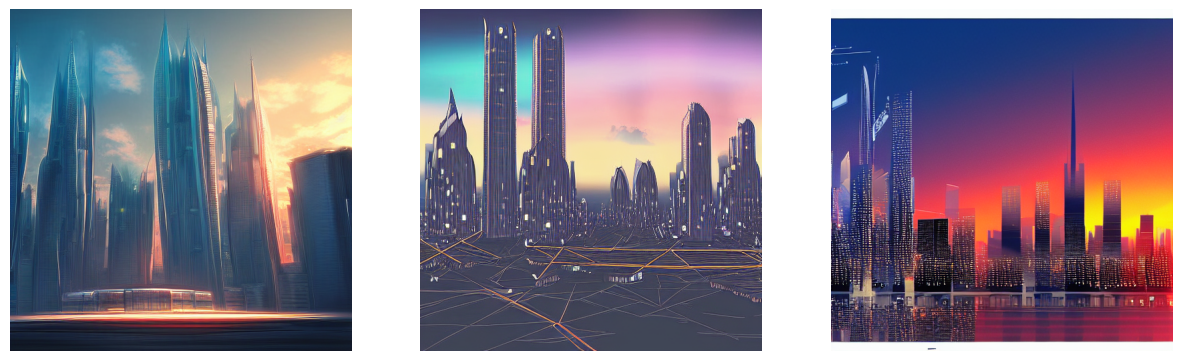

In [8]:
# quick function to show the images, copied this pattern from tf docs
def show(imgs):
    plt.figure(figsize=(15,5))
    for i in range(len(imgs)):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
    plt.savefig('output.png')
    plt.show()

show(imgs)

looks decent, trying another prompt below to compare

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 617ms/step


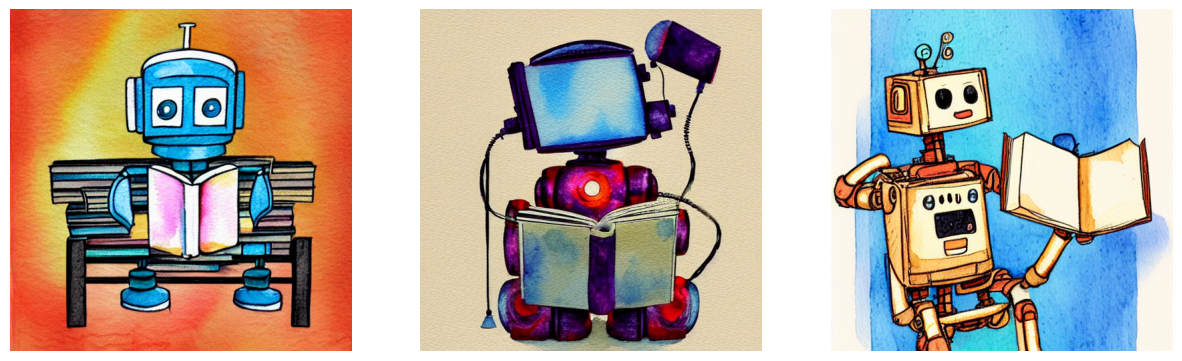

In [9]:
prompt2 = "a cute robot reading a book, watercolor style"
imgs2 = model.text_to_image(prompt2, batch_size=3)
show(imgs2)

saved the last output as output.png, will use this for the submission